# Synent Technologies Data Science Internship - Task 1: Data Cleaning & Preprocessing

**Intern: [Rishabh Sakariya]**


## 1. Introduction

This notebook serves as the submission for Task 1 of the Synent Technologies Data Science Internship, focusing on Data Cleaning and Preprocessing using the Titanic dataset. The goal is to transform raw, potentially messy data into a clean, structured, and usable format for subsequent analysis and model building. This task is crucial as data quality significantly impacts the insights derived and the performance of machine learning models.

We will leverage Python's powerful data science libraries – Pandas, NumPy, Matplotlib, and Seaborn – to perform a comprehensive data cleaning workflow, including handling missing values, managing duplicates, renaming columns for clarity, converting data types, and visualizing key aspects of the cleaned dataset.

---

## 2. Setup: Import Libraries

First, we need to import all the necessary Python libraries.
*   **Pandas:** For data manipulation and analysis.
*   **NumPy:** For numerical operations, especially with arrays.
*   **Matplotlib.pyplot:** For creating static, interactive, and animated visualizations.
*   **Seaborn:** For creating informative and attractive statistical graphics based on Matplotlib.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Data Loading and Initial Exploration

In this section, we will load the Titanic training dataset (`train.csv`) and perform an initial exploration to understand its structure, content, and identify any immediate issues.

### Load Dataset

We will load the `train.csv` file into a Pandas DataFrame. The dataset is publicly available on Kaggle.

In [ ]:
# URL for the Titanic train dataset on Kaggle (raw data link)
# Make sure to use the direct raw CSV link or download it locally
titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("Titanic dataset loaded successfully!")

Titanic dataset loaded successfully!


### Display First 5 Rows

Viewing the first few rows helps us get a quick overview of the data, including column names and the type of values they contain.

In [ ]:
print("First 5 rows of the dataset:")
titanic_df.head()

First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Dataset Shape

The shape of the dataset (number of rows and columns) gives us an idea of its size.

In [ ]:
print("Shape of the dataset (rows, columns):")
titanic_df.shape

Shape of the dataset (rows, columns):


(891, 12)

### Dataset Information

The `info()` method provides a concise summary of the DataFrame, including the number of non-null entries in each column and their data types. This is crucial for identifying missing values and understanding data types.

In [ ]:
print("Information about the dataset:")
titanic_df.info()

Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Statistical Summary

The `describe()` method generates descriptive statistics of the numerical columns, such as count, mean, standard deviation, min, max, and quartile values. This helps in understanding the distribution and central tendency of the data.

In [ ]:
print("Statistical summary of the numerical columns:")
titanic_df.describe()

Statistical summary of the numerical columns:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Data Cleaning Workflow

This section outlines the process of cleaning and preprocessing the Titanic dataset. We will systematically address missing values, duplicates, column naming conventions, and data types.

### Check Missing Values

Identifying missing values is the first step in handling them. We will count the number of null entries for each column.

In [ ]:
print("Number of missing values per column:")
titanic_df.isnull().sum()

Number of missing values per column:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Insight:**
*   **Age:** Has `177` missing values, which is a significant portion.
*   **Cabin:** Has `687` missing values, indicating that most entries are missing.
*   **Embarked:** Has `2` missing values, a relatively small number.

### Handle Missing Values

Based on the missing values identified, we will apply appropriate strategies for each column.

#### Fill 'Age' with Median

The 'Age' column has numerical data and a considerable number of missing values. Filling with the median is a robust strategy as it is less sensitive to outliers compared to the mean.

In [ ]:
# Calculate the median age
median_age = titanic_df['Age'].median()
# Fill missing 'Age' values with the median
titanic_df['Age'].fillna(median_age, inplace=True)

print(f"Missing 'Age' values filled with median: {median_age}")

Missing 'Age' values filled with median: 28.0


/tmp/ipykernel_1358/4159928031.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(median_age, inplace=True)


#### Fill 'Embarked' with Mode

The 'Embarked' column is categorical and has only two missing values. Filling with the mode (most frequent value) is a suitable approach for categorical data.

In [ ]:
# Calculate the mode of 'Embarked'
mode_embarked = titanic_df['Embarked'].mode()[0] # .mode() returns a Series, so we take the first element
# Fill missing 'Embarked' values with the mode
titanic_df['Embarked'].fillna(mode_embarked, inplace=True)

print(f"Missing 'Embarked' values filled with mode: {mode_embarked}")

Missing 'Embarked' values filled with mode: S


/tmp/ipykernel_1358/2452814250.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Embarked'].fillna(mode_embarked, inplace=True)


#### Drop 'Cabin' Column

The 'Cabin' column has a very high percentage of missing values (`687` out of `891`). Imputing such a large number of missing values might introduce significant bias, and the column might not provide meaningful insights. Therefore, we will drop this column.

In [ ]:
# Drop the 'Cabin' column
titanic_df.drop('Cabin', axis=1, inplace=True)

print("'Cabin' column dropped successfully.")

'Cabin' column dropped successfully.


**Verify Missing Values After Handling:**

Let's check the missing values again to confirm that our handling strategies were effective.

In [ ]:
print("Missing values after handling:")
titanic_df.isnull().sum()

Missing values after handling:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**Insight:** All missing values have been successfully addressed.

### Check and Remove Duplicates

Duplicate rows can bias analysis. We'll check for any exact duplicate rows and remove them if found.

In [ ]:
# Check for duplicate rows
num_duplicates = titanic_df.duplicated().sum()
print(f"Number of duplicate rows found: {num_duplicates}")

if num_duplicates > 0:
    # Remove duplicate rows
    titanic_df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New shape of the dataset after removing duplicates: {titanic_df.shape}")
else:
    print("No duplicate rows to remove.")

Number of duplicate rows found: 0
No duplicate rows to remove.


**Insight:** No duplicate rows were found in this dataset.

### Rename Columns

Renaming columns to a more consistent and readable format improves code readability and maintainability.

In [ ]:
# Define a dictionary for renaming
column_rename_map = {
    'PassengerId': 'Passenger_ID',
    'Pclass': 'Passenger_Class',
    'Sex': 'Gender'
}

# Rename the columns
titanic_df.rename(columns=column_rename_map, inplace=True)

print("Columns renamed successfully.")
print("New column names:")
titanic_df.columns

Columns renamed successfully.
New column names:


Index(['Passenger_ID', 'Survived', 'Passenger_Class', 'Name', 'Gender', 'Age',
       'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

### Convert Data Types

Ensuring columns have appropriate data types is essential for correct analysis and memory efficiency. We'll convert categorical columns to `category` type.

In [ ]:
# Convert 'Survived', 'Passenger_Class', 'Gender', 'Embarked' to category type
titanic_df['Survived'] = titanic_df['Survived'].astype('category')
titanic_df['Passenger_Class'] = titanic_df['Passenger_Class'].astype('category')
titanic_df['Gender'] = titanic_df['Gender'].astype('category')
titanic_df['Embarked'] = titanic_df['Embarked'].astype('category')

print("Data types converted successfully.")

Data types converted successfully.


### Verify Cleaned Dataset

After all cleaning and preprocessing steps, it's good practice to verify the dataset's state.

In [ ]:
print("First 5 rows of the cleaned dataset:")
titanic_df.head()

First 5 rows of the cleaned dataset:


,Passenger_ID,Survived,Passenger_Class,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
print("Information about the cleaned dataset:")
titanic_df.info()

Information about the cleaned dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Passenger_ID     891 non-null    int64   
 1   Survived         891 non-null    category
 2   Passenger_Class  891 non-null    category
 3   Name             891 non-null    object  
 4   Gender           891 non-null    category
 5   Age              891 non-null    float64 
 6   SibSp            891 non-null    int64   
 7   Parch            891 non-null    int64   
 8   Ticket           891 non-null    object  
 9   Fare             891 non-null    float64 
 10  Embarked         891 non-null    category
dtypes: category(4), float64(2), int64(3), object(2)
memory usage: 52.8+ KB


**Insight:** The dataset is now clean: no missing values, no duplicates, clear column names, and appropriate data types for analysis.

In [ ]:
print("Missing values in the current DataFrame:")
titanic_df.isnull().sum()

Missing values in the current DataFrame:


,0
Passenger_ID,0
Survived,0
Passenger_Class,0
Name,0
Gender,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## 5. Data Visualization and Insights

Visualizations help in understanding the cleaned data, confirming our preprocessing steps, and gaining initial insights into the dataset's characteristics.

### Missing Values Bar Chart

Before handling, we would have seen bars for 'Age', 'Cabin', 'Embarked'. Now, this chart visually confirms that no missing values remain.

/tmp/ipykernel_1358/2303563086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=titanic_df.isnull().sum().index, y=titanic_df.isnull().sum().values, palette='viridis')


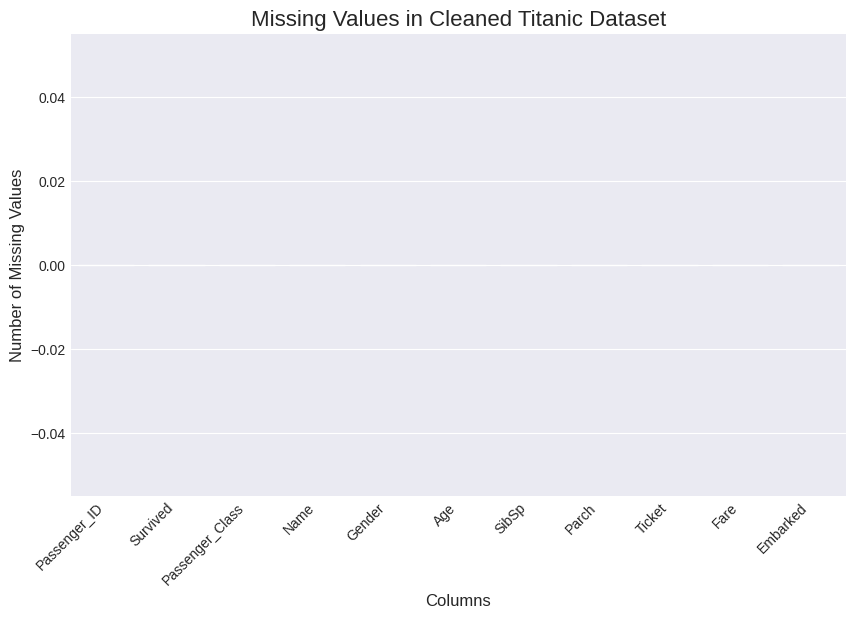

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=titanic_df.isnull().sum().index, y=titanic_df.isnull().sum().values, palette='viridis')
plt.title('Missing Values in Cleaned Titanic Dataset', fontsize=16)
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Number of Missing Values', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight:** As expected, this bar chart shows zero missing values for all columns, confirming the success of our missing value imputation and column dropping strategies.

### Survival Count Bar Chart

This chart shows the distribution of passengers who survived versus those who did not.

/tmp/ipykernel_1358/2695231019.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=titanic_df, palette='pastel')


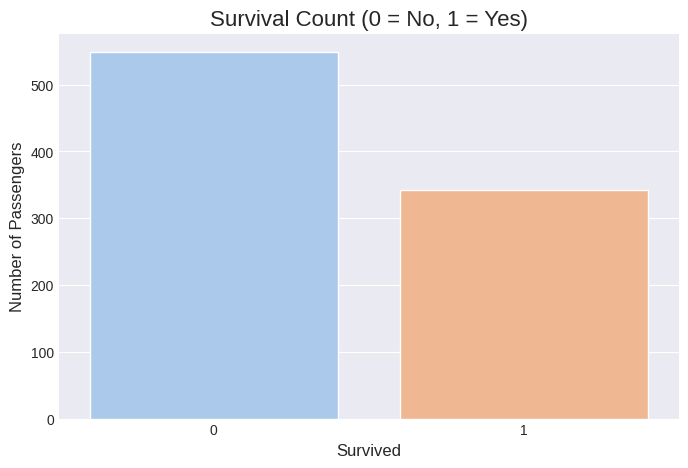

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', data=titanic_df, palette='pastel')
plt.title('Survival Count (0 = No, 1 = Yes)', fontsize=16)
plt.xlabel('Survived', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.show()

**Insight:** A majority of the passengers (approximately 550) did not survive, while a smaller portion (around 340) managed to survive the Titanic disaster. This indicates a challenging survival rate.

### Gender Distribution Chart

Understanding the gender breakdown of passengers is a key demographic insight.

/tmp/ipykernel_1358/3098136472.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=titanic_df, palette='coolwarm')


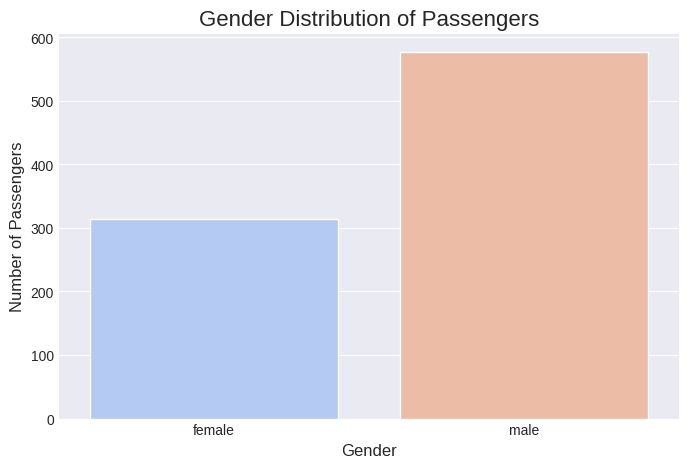

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', data=titanic_df, palette='coolwarm')
plt.title('Gender Distribution of Passengers', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.show()

**Insight:** There were significantly more male passengers than female passengers on the Titanic. This imbalance might have implications for survival rates, given the "women and children first" protocol.

### Passenger Class Distribution Chart

This visualization shows how passengers were distributed across different economic classes (1st, 2nd, 3rd).

/tmp/ipykernel_1358/1329973185.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Passenger_Class', data=titanic_df, palette='rocket')


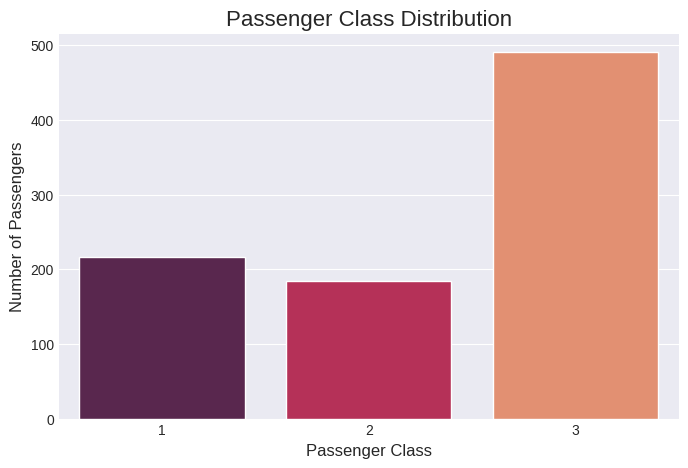

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Passenger_Class', data=titanic_df, palette='rocket')
plt.title('Passenger Class Distribution', fontsize=16)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.show()

**Insight:** The largest number of passengers traveled in 3rd class, followed by 1st class, and then 2nd class. This class distribution could be a critical factor influencing survival.

## 6. Save Cleaned Dataset

Finally, we save the cleaned and preprocessed dataset to a new CSV file named `Titanic_Cleaned.csv`. This prepared dataset can now be used for further exploratory data analysis (EDA), feature engineering, and machine learning model training.

In [ ]:
# Save the cleaned DataFrame to a new CSV file
titanic_df.to_csv('Titanic_Cleaned.csv', index=False)

print("Cleaned dataset saved as 'Titanic_Cleaned.csv'.")
print("First 5 rows of the saved CSV:")
pd.read_csv('Titanic_Cleaned.csv').head()

Cleaned dataset saved as 'Titanic_Cleaned.csv'.
First 5 rows of the saved CSV:


,Passenger_ID,Survived,Passenger_Class,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## 7. Conclusion

This notebook successfully demonstrates a complete data cleaning and preprocessing workflow on the Titanic dataset. We started with raw data, identified various data quality issues, and systematically addressed them.

*   **Missing values** in 'Age' were imputed with the median, 'Embarked' with the mode, and the 'Cabin' column was dropped due to excessive missingness.
*   **Duplicate rows** were checked for and confirmed to be absent.
*   **Column names** were standardized for better readability (e.g., 'PassengerId' to 'Passenger_ID').
*   **Data types** were optimized by converting relevant columns to 'category' type, which is efficient for categorical data.

The resulting `Titanic_Cleaned.csv` dataset is now ready for deeper analysis, feature engineering, and building predictive models. The visualizations provided initial insights into survival rates and demographic distributions, setting the stage for more complex analyses.

## 8. Project Summary

This project involved performing comprehensive data cleaning and preprocessing on the raw Titanic dataset (`train.csv`). Key steps included handling missing values through imputation (median for 'Age', mode for 'Embarked') and column removal ('Cabin'), checking for duplicates, renaming columns for clarity, and converting data types. The cleaned dataset was then used to generate descriptive visualizations, providing initial insights into passenger demographics and survival outcomes. The final output is a clean, ready-to-analyze dataset (`Titanic_Cleaned.csv`) and a detailed workflow presented in a Google Colab notebook.